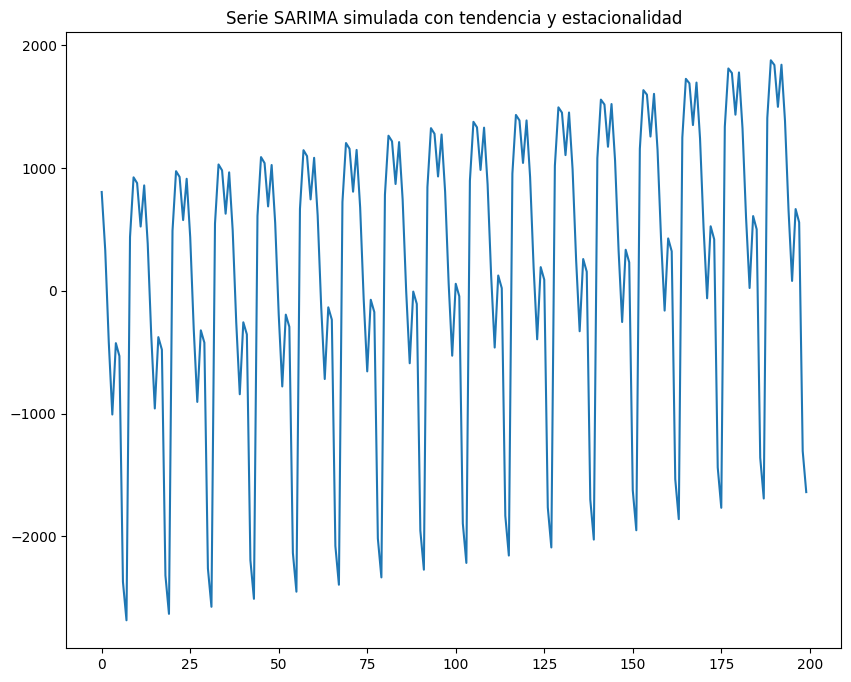

In [25]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")
import xgboost as xgb

# Definimos el modelo SARIMA(1,1,1)(1,1,1,12)
model = SARIMAX(
    endog=[0],  # Dummy para inicializar
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

# Definimos parámetros (phi, theta, etc.)
# Deben coincidir con el número de parámetros que el modelo espera
params = [0.5, 0.4, 0.3, 0.2, 1]  
# -> AR(1), MA(1), SAR(1), SMA(1), varianza del error

# Simulación de 200 puntos
sim = model.simulate(params=params, nsimulations=200)

pd.Series(sim).plot(title="Serie SARIMA simulada con tendencia y estacionalidad")
plt.show()


In [7]:
import yfinance as yf
import matplotlib.pyplot as plt

# Descargar Apple desde 2015
data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")



C:\Users\roman\AppData\Local\Temp\ipykernel_4904\1382921730.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed


C:\Users\roman\AppData\Local\Temp\ipykernel_4904\3011473517.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = data['Close'].resample('M').mean()


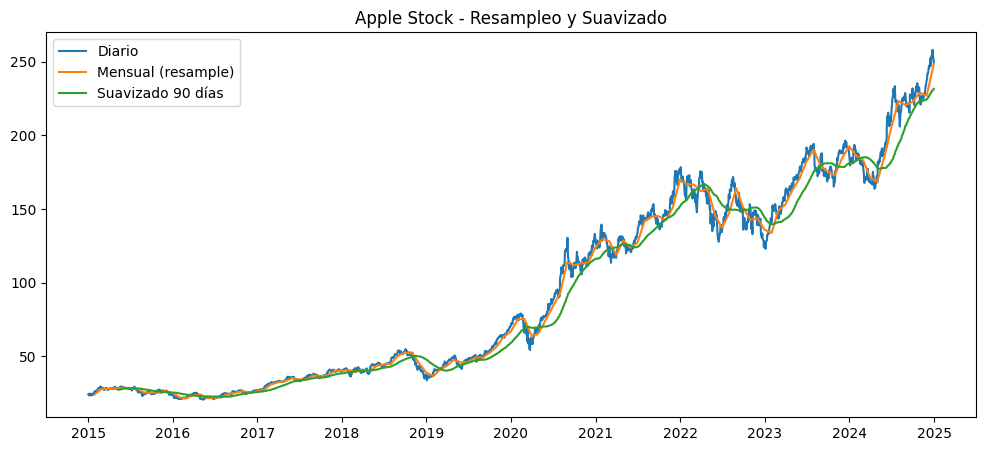

In [9]:
# Resampleo mensual
monthly = data['Close'].resample('M').mean()

# Suavizado con media móvil de 90 días
smoothed = data['Close'].rolling(window=90).mean()

plt.figure(figsize=(12,5))
plt.plot(data['Close'], label="Diario")
plt.plot(monthly, label="Mensual (resample)")
plt.plot(smoothed, label="Suavizado 90 días")
plt.legend()
plt.title("Apple Stock - Resampleo y Suavizado")
plt.show()

C:\Users\roman\AppData\Local\Temp\ipykernel_4904\2811206708.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  serie_mensual = serie.resample('M').mean()


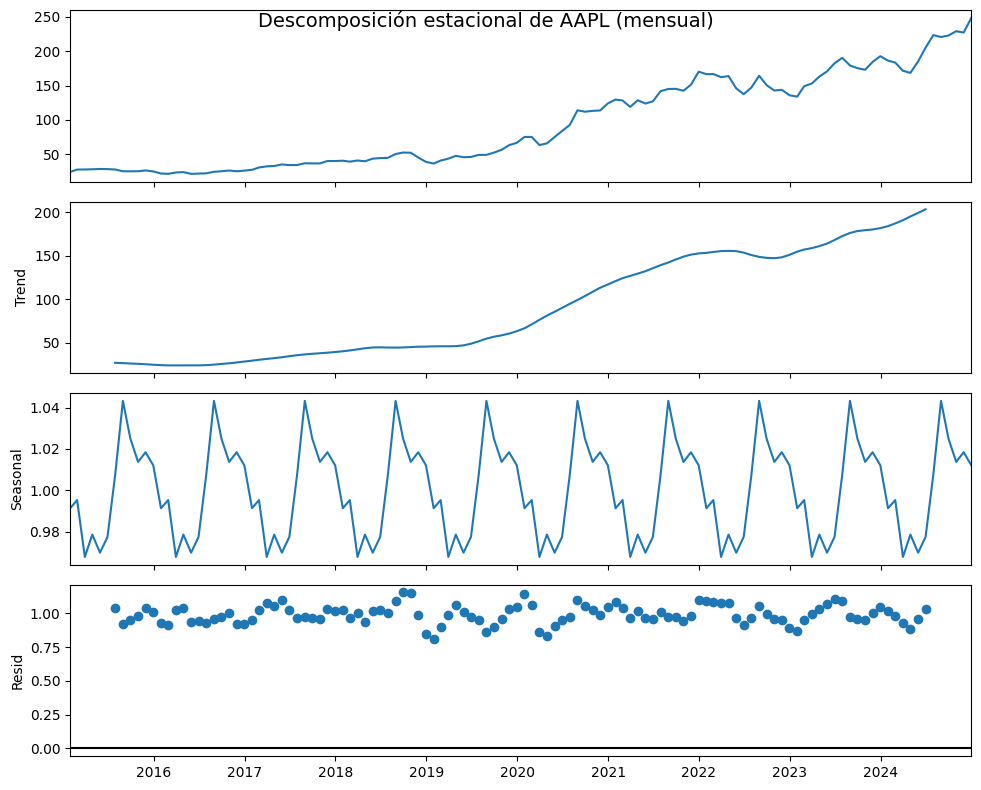

In [10]:
# 2. Nos quedamos con el precio de cierre
serie = data['Close']

# 3. Resampleo mensual (para captar estacionalidad más clara)
serie_mensual = serie.resample('M').mean()

# 4. Descomposición estacional
#   - model='multiplicative' se usa si la varianza crece con la serie
#   - period=12 asume estacionalidad anual en datos mensuales
resultado = seasonal_decompose(serie_mensual, model='multiplicative', period=12)

# 5. Graficar los componentes
plt.rcParams.update({'figure.figsize': (10,8)})
resultado.plot()
plt.suptitle("Descomposición estacional de AAPL (mensual)", fontsize=14)
plt.show()

In [13]:
def make_features(data, max_lag):
    feature= data.columns[0]    
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data[feature].shift(lag)
    return data.dropna()

In [40]:
max_lags=21
data_with_lags=make_features(data[['Close']],max_lags)
train, test = train_test_split(data_with_lags, shuffle=False, test_size=0.2)
features_train = train.drop(['Close'],axis=1)
target_train = train['Close']
features_test = test.drop(['Close'],axis=1)
target_test = test['Close']

In [41]:
features_train.head()

Price,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,...,lag_12,lag_13,lag_14,lag_15,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21
Ticker,,,,,,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2015-02-03,26.324772,25.998573,26.384693,25.588049,24.218885,25.097639,25.071003,24.942297,24.309868,24.125687,...,23.704060,24.365343,24.458542,24.243299,24.855759,24.829130,23.910433,23.579794,23.577576,24.261049
2015-02-04,26.329214,26.324772,25.998573,26.384693,25.588049,24.218885,25.097639,25.071003,24.942297,24.309868,...,23.519880,23.704060,24.365343,24.458542,24.243299,24.855759,24.829130,23.910433,23.579794,23.577576
2015-02-05,26.531155,26.329214,26.324772,25.998573,26.384693,25.588049,24.218885,25.097639,25.071003,24.942297,...,24.125687,23.519880,23.704060,24.365343,24.458542,24.243299,24.855759,24.829130,23.910433,23.579794
2015-02-06,26.720518,26.531155,26.329214,26.324772,25.998573,26.384693,25.588049,24.218885,25.097639,25.071003,...,24.309868,24.125687,23.519880,23.704060,24.365343,24.458542,24.243299,24.855759,24.829130,23.910433
2015-02-09,26.495506,26.720518,26.531155,26.329214,26.324772,25.998573,26.384693,25.588049,24.218885,25.097639,...,24.942297,24.309868,24.125687,23.519880,23.704060,24.365343,24.458542,24.243299,24.855759,24.829130


In [42]:
# Parámetros de entrenamiento
params = {
    'objective': 'reg:absoluteerror',  # regresión
    'eval_metric': 'mae',            # métrica de evaluación
    'eta': 0.1,                       # learning rate
    'max_depth': 10,                  # profundidad máxima
    'verbosity': 0
}

In [54]:
preds_train+preds_xgb

ValueError: operands could not be broadcast together with shapes (1996,) (499,) 

In [63]:
models=[]
for n_lags in range(1,max_lags+1):
    print(f"Training for {n_lags} lags")
    # Convertir datasets al formato de XGBoost
    dtrain = xgb.DMatrix(features_train.iloc[:,:n_lags], label=target_train)
    dtest = xgb.DMatrix(features_test.iloc[:,:n_lags], label=target_test)


    # Entrenamiento del modelo
    xgb_model = xgb.train(params, dtrain, num_boost_round=250)

    # Predicciones
    preds_xgb = xgb_model.predict(dtest)
    preds_train = xgb_model.predict(dtrain)

    predicted=(
        data_with_lags
        .assign(
                predicted = lambda df: np.concatenate([preds_train,preds_xgb]),
                label = lambda df: len(preds_train)*['train'] + len(preds_xgb)*['test']
            )[['predicted']]
    )

    # Calcular RMSE
    mae_xgb = mean_absolute_error(target_test, preds_xgb)
    print(f"MAE for test: {mae_xgb:.2f} ")
    models.append({'model':xgb_model,'mae_test':mae_xgb,'pred_test':preds_xgb,'preds_train':preds_train,'predicted_serie':predicted})


Training for 1 lags
MAE for test: 19.40 
Training for 2 lags
MAE for test: 19.47 
Training for 3 lags
MAE for test: 19.47 
Training for 4 lags
MAE for test: 19.31 
Training for 5 lags
MAE for test: 20.05 
Training for 6 lags
MAE for test: 20.58 
Training for 7 lags
MAE for test: 20.50 
Training for 8 lags
MAE for test: 20.73 
Training for 9 lags
MAE for test: 20.95 
Training for 10 lags
MAE for test: 19.89 
Training for 11 lags
MAE for test: 19.04 
Training for 12 lags
MAE for test: 18.97 
Training for 13 lags
MAE for test: 18.85 
Training for 14 lags
MAE for test: 18.33 
Training for 15 lags
MAE for test: 18.88 
Training for 16 lags
MAE for test: 18.93 
Training for 17 lags
MAE for test: 17.80 
Training for 18 lags
MAE for test: 19.11 
Training for 19 lags
MAE for test: 18.58 
Training for 20 lags
MAE for test: 20.85 
Training for 21 lags
MAE for test: 20.69 


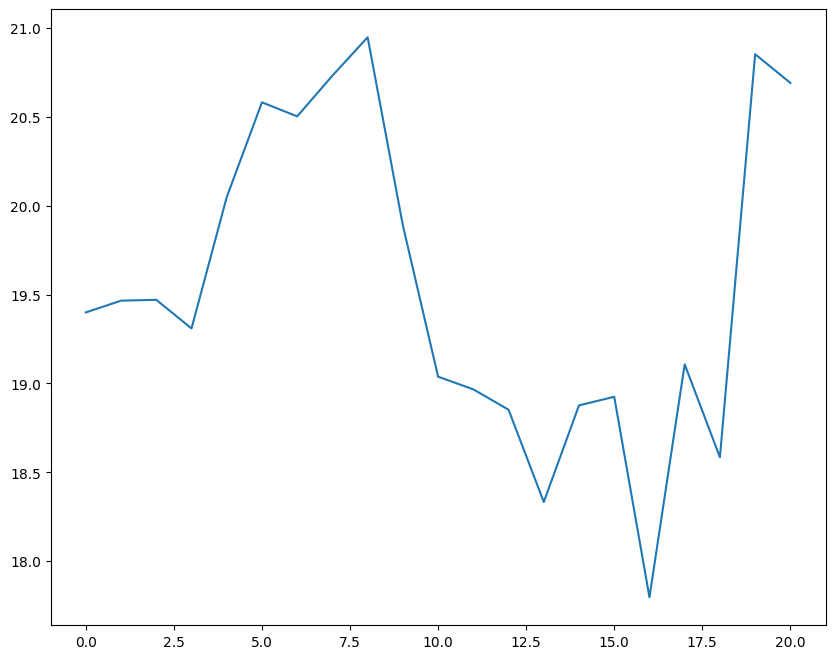

In [64]:
plt.plot([mm['mae_test'] for mm in models])

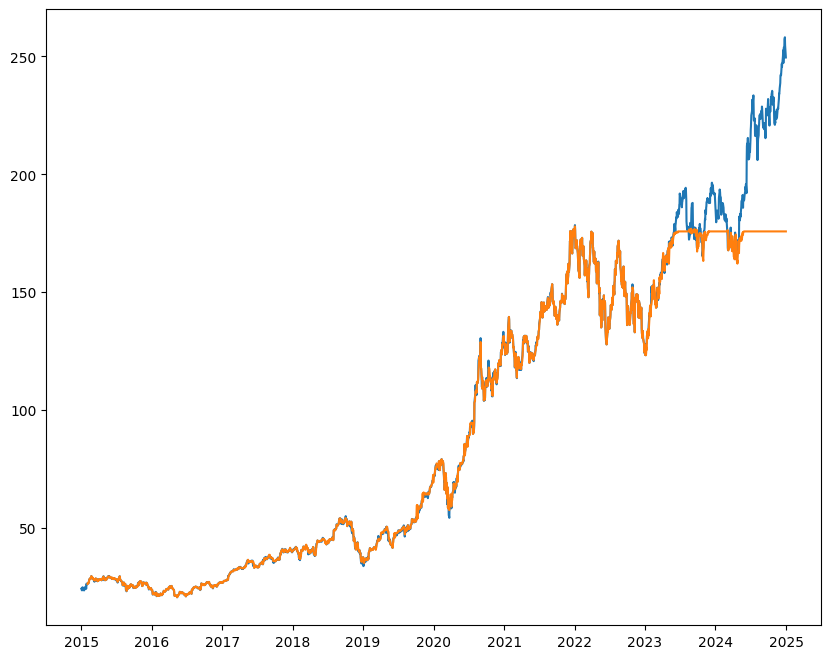

In [65]:
plt.plot(data[['Close']])
plt.plot(models[15]['predicted_serie']['predicted'])

In [ ]:
data[['Close']]

In [ ]:
# Convertir datasets al formato de XGBoost
dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)



# Entrenamiento del modelo
xgb_model = xgb.train(params, dtrain, num_boost_round=100)

# Predicciones
preds_xgb = xgb_model.predict(dtest)

# Calcular RMSE
rmse_xgb = mean_absolute_error(y_test, preds_xgb)

print(f"RMSE XGBoost: {rmse_xgb:.2f}")